Bài toán Hồi quy (Regression)

Mục tiêu: Dự đoán 'deal_probability' (0.0 -> 1.0)

Đánh giá: Root Mean Squared Error (RMSE)

**Khám phá và Phân tích Dữ liệu (EDA)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../input/train.csv')
df.head()

,item_id,user_id,region,city,parent_category_name,category_name,param_1,param_2,param_3,title,description,price,item_seq_number,activation_date,user_type,image,image_top_1,deal_probability
0,b912c3c6a6ad,e00f8ff2eaf9,Свердловская область,Екатеринбург,Личные вещи,Товары для детей и игрушки,Постельные принадлежности,NaN,NaN,Кокоби(кокон для сна),"Кокон для сна малыша,пользовались меньше месяц...",400.0,2,2017-03-28,Private,d10c7e016e03247a3bf2d13348fe959fe6f436c1caf64c...,1008.0,0.12789
1,2dac0150717d,39aeb48f0017,Самарская область,Самара,Для дома и дачи,Мебель и интерьер,Другое,NaN,NaN,Стойка для Одежды,"Стойка для одежды, под вешалки. С бутика.",3000.0,19,2017-03-26,Private,79c9392cc51a9c81c6eb91eceb8e552171db39d7142700...,692.0,0.00000
2,ba83aefab5dc,91e2f88dd6e3,Ростовская область,Ростов-на-Дону,Бытовая электроника,Аудио и видео,"Видео, DVD и Blu-ray плееры",NaN,NaN,Philips bluray,"В хорошем состоянии, домашний кинотеатр с blu ...",4000.0,9,2017-03-20,Private,b7f250ee3f39e1fedd77c141f273703f4a9be59db4b48a...,3032.0,0.43177
3,02996f1dd2ea,bf5cccea572d,Татарстан,Набережные Челны,Личные вещи,Товары для детей и игрушки,Автомобильные кресла,NaN,NaN,Автокресло,Продам кресло от0-25кг,2200.0,286,2017-03-25,Company,e6ef97e0725637ea84e3d203e82dadb43ed3cc0a1c8413...,796.0,0.80323
4,7c90be56d2ab,ef50846afc0b,Волгоградская область,Волгоград,Транспорт,Автомобили,С пробегом,ВАЗ (LADA),2110,"ВАЗ 2110, 2003",Все вопросы по телефону.,40000.0,3,2017-03-16,Private,54a687a3a0fc1d68aed99bdaaf551c5c70b761b16fd0a2...,2264.0,0.20797


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503424 entries, 0 to 1503423
Data columns (total 18 columns):
 #   Column                Non-Null Count    Dtype  
---  ------                --------------    -----  
 0   item_id               1503424 non-null  object 
 1   user_id               1503424 non-null  object 
 2   region                1503424 non-null  object 
 3   city                  1503424 non-null  object 
 4   parent_category_name  1503424 non-null  object 
 5   category_name         1503424 non-null  object 
 6   param_1               1441848 non-null  object 
 7   param_2               848882 non-null   object 
 8   param_3               640859 non-null   object 
 9   title                 1503424 non-null  object 
 10  description           1387148 non-null  object 
 11  price                 1418062 non-null  float64
 12  item_seq_number       1503424 non-null  int64  
 13  activation_date       1503424 non-null  object 
 14  user_type             1503424 non-

In [4]:
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Số lượng thiếu': missing_values, 'Tỷ lệ %': missing_percent})
print(missing_df[missing_df['Số lượng thiếu'] > 0])

             Số lượng thiếu    Tỷ lệ %
param_1               61576   4.095718
param_2              654542  43.536753
param_3              862565  57.373369
description          116276   7.734079
price                 85362   5.677839
image                112588   7.488772
image_top_1          112588   7.488772


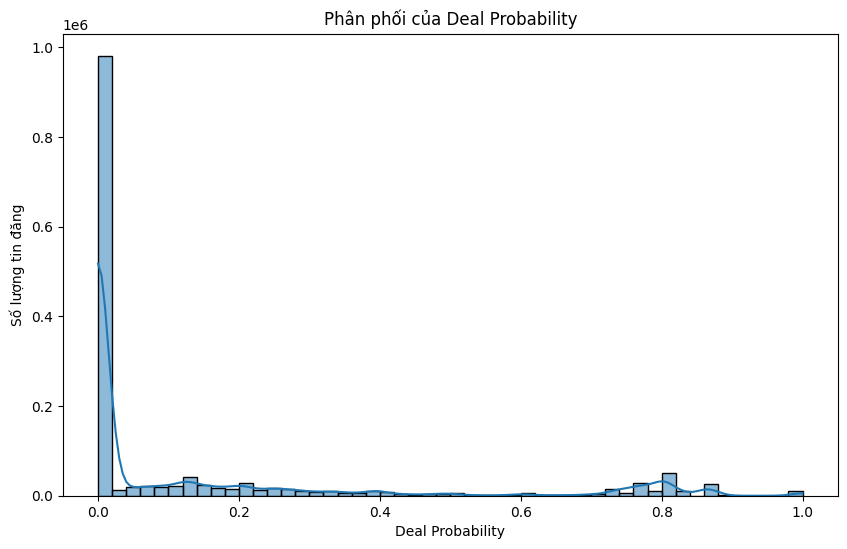

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['deal_probability'], bins=50, kde=True)
plt.title('Phân phối của Deal Probability')
plt.xlabel('Deal Probability')
plt.ylabel('Số lượng tin đăng')
plt.show()

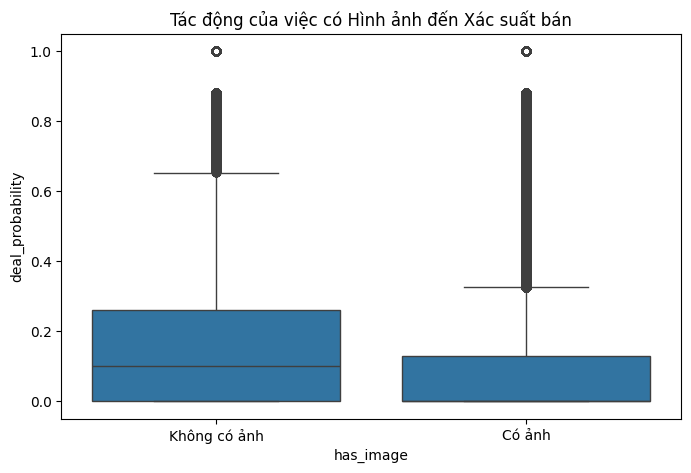

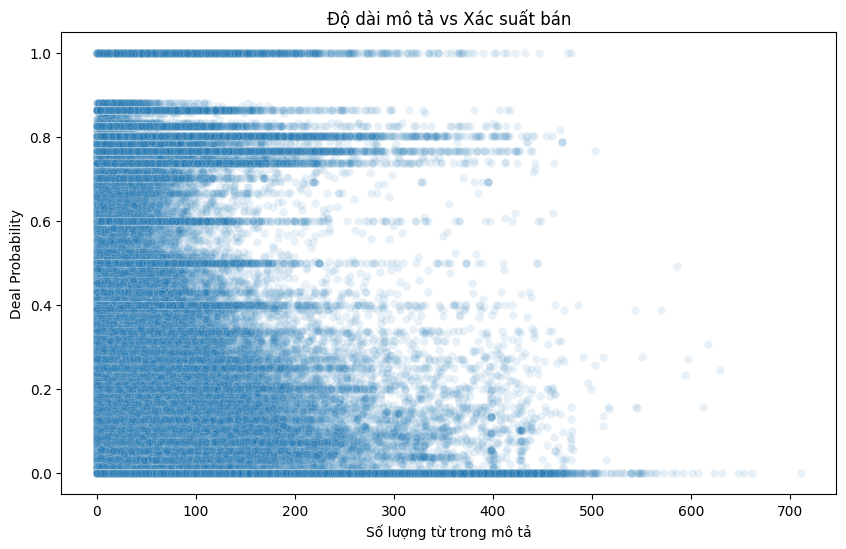

In [6]:
# 1. Có ảnh vs Không có ảnh
df['has_image'] = df['image'].notnull().astype(int)

plt.figure(figsize=(8, 5))
sns.boxplot(x='has_image', y='deal_probability', data=df)
plt.title('Tác động của việc có Hình ảnh đến Xác suất bán')
plt.xticks([0, 1], ['Không có ảnh', 'Có ảnh'])
plt.show()
# Nhận xét thực tế: Tin có ảnh thường có giá trị deal_probability trung bình cao hơn.

# 2. Phân tích độ dài mô tả (Description Length)
df['desc_len'] = df['description'].fillna("").apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.scatterplot(x='desc_len', y='deal_probability', data=df, alpha=0.1)
plt.title('Độ dài mô tả vs Xác suất bán')
plt.xlabel('Số lượng từ trong mô tả')
plt.ylabel('Deal Probability')
plt.show()
# Nhận xét: Không phải viết càng dài thì càng dễ bán, thường có một độ dài "vừa đủ" mang lại hiệu quả tốt nhất.

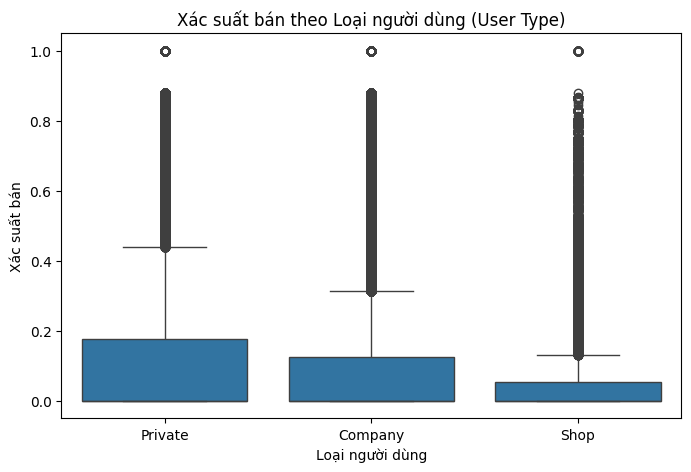

In [12]:
plt.figure(figsize=(8, 5))
# Dùng barplot để xem giá trị của deal_probability theo từng loại user
sns.boxplot(x='user_type', y='deal_probability', data=df)
plt.title('Xác suất bán theo Loại người dùng (User Type)')
plt.ylabel('Xác suất bán')
plt.xlabel('Loại người dùng')
plt.show()

# NHẬN XÉT (Thực tế từ dataset Avito):
# - Người dùng 'Private' (cá nhân thanh lý đồ cũ) thường có xác suất bán thành công CAO NHẤT.
# - 'Company' hoặc 'Shop' thường có tỷ lệ bán thấp hơn trên nền tảng rao vặt này.


/tmp/ipykernel_32987/1728226343.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_mean_deal.values, y=category_mean_deal.index, palette='viridis')


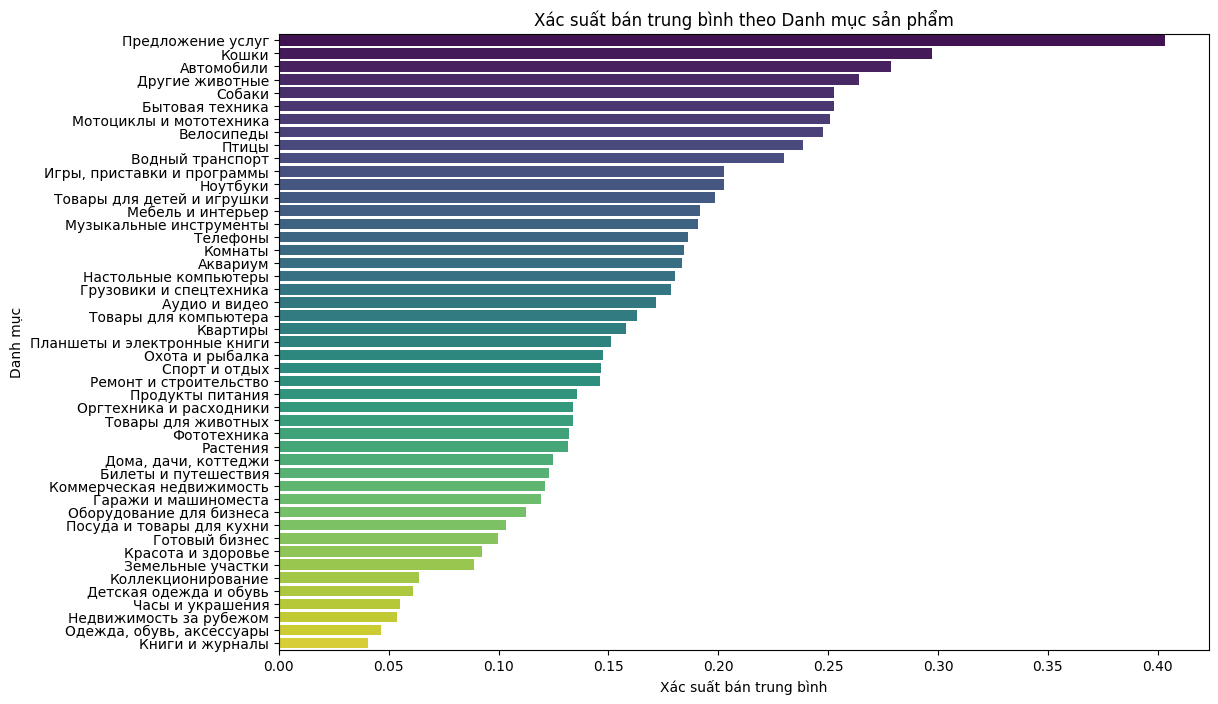

In [13]:
plt.figure(figsize=(12, 8))
# Tính trung bình deal_probability cho mỗi danh mục và sắp xếp giảm dần
category_mean_deal = df.groupby('category_name')['deal_probability'].mean().sort_values(ascending=False)

sns.barplot(x=category_mean_deal.values, y=category_mean_deal.index, palette='viridis')
plt.title('Xác suất bán trung bình theo Danh mục sản phẩm')
plt.xlabel('Xác suất bán trung bình')
plt.ylabel('Danh mục')
plt.show()

# NHẬN XÉT:
# - Các dịch vụ (Services) hoặc đồ trẻ em (Children's products) thường có xác suất bán cao.
# - Trong khi đó, Bất động sản (Real Estate) hoặc Ô tô (Cars) có xác suất chốt đơn trực tuyến rất thấp (thường phải gặp mặt).


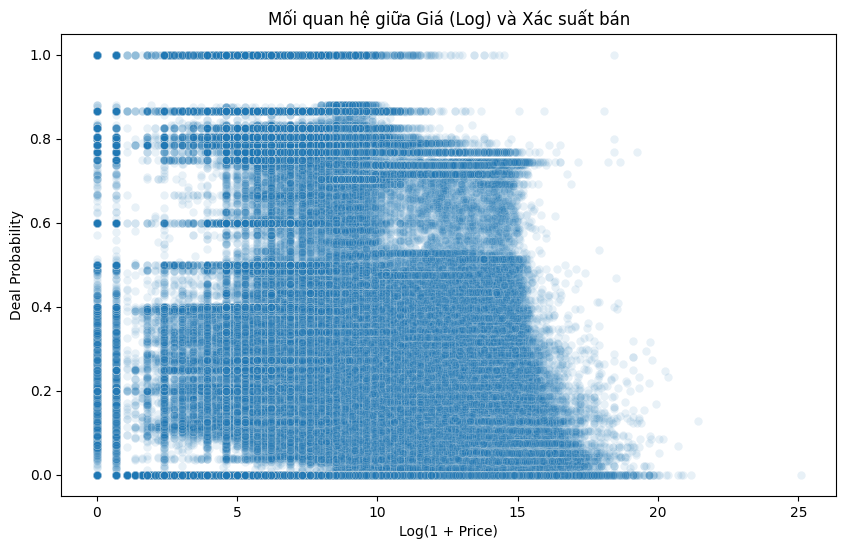

In [27]:
# Giá tiền (Price) thường bị lệch (skewed) do có vài món đồ cực kỳ đắt, dùng log(1 + price) để đồ thị dễ nhìn hơn.
df['log_price'] = np.log1p(df['price'])

plt.figure(figsize=(10, 6))
# plt.hexbin(x=df['log_price'], y=df['deal_probability'], gridsize=50, cmap='Blues', mincnt=1)
sns.scatterplot(x='log_price', y='deal_probability', data=df, alpha=0.1)
# cb = plt.colorbar(label='Số lượng tin đăng')
plt.title('Mối quan hệ giữa Giá (Log) và Xác suất bán')
plt.xlabel('Log(1 + Price)')
plt.ylabel('Deal Probability')
plt.show()

# NHẬN XÉT:
# - Có một cụm dữ liệu lớn tập trung ở mức giá thấp và xác suất bán là 0. 
# - Giá quá cao gần như chắc chắn xác suất bán = 0 (trên nền tảng online).
# - Mối quan hệ này không phải tuyến tính hoàn toàn, do đó mạng Nơ-ron hoặc mô hình Cây (như LightGBM) sẽ học rất tốt đặc trưng này.


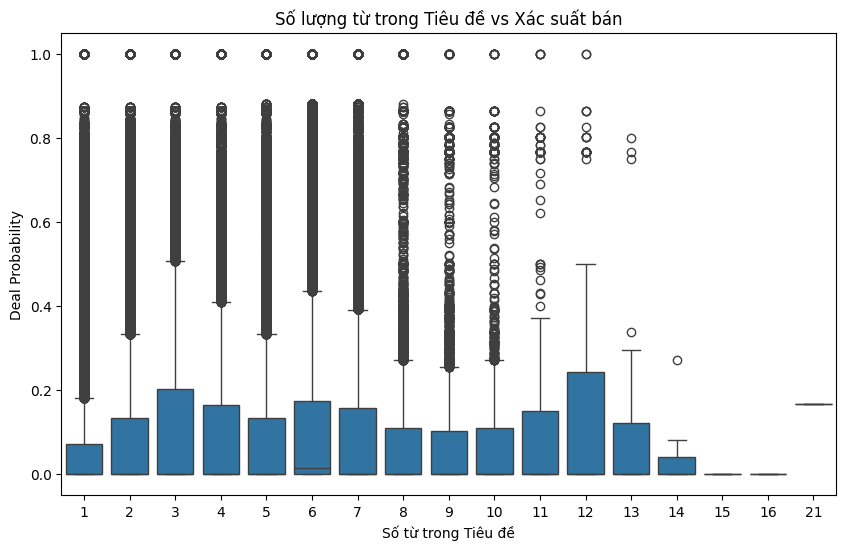

In [17]:
# Tính độ dài của title (số lượng từ)
df['title_word_count'] = df['title'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.boxplot(x='title_word_count', y='deal_probability', data=df)
plt.title('Số lượng từ trong Tiêu đề vs Xác suất bán')
plt.xlabel('Số từ trong Tiêu đề')
plt.ylabel('Deal Probability')
plt.show()

# NHẬN XÉT:
# - Tiêu đề chỉ có 1 từ thường có xác suất bán thấp (ví dụ chỉ ghi "Áo" thay vì "Áo khoác nam mùa đông").
# - Độ dài tiêu đề tối ưu thường rơi vào khoảng 3 đến 5 từ.